# Naive Bayes Classification on Supermarket Sales Dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
df = pd.read_csv('supermarket_sales.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,state
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,"917 1st St, Dallas, TX 75001"
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,"82 Chestnut St, Boston, MA 02215"
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,"Spruce St, Los Angeles, CA 90001"
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,"Spruce St, Los Angeles, CA 90001"
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,"333 8th St, Los Angeles, CA 90001"


# Data Visualization
Let's explore the dataset visually before moving to predictions.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

C:\Users\USER\AppData\Local\Temp\ipykernel_14576\2764333307.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Customer type', data=df, palette='Set2')


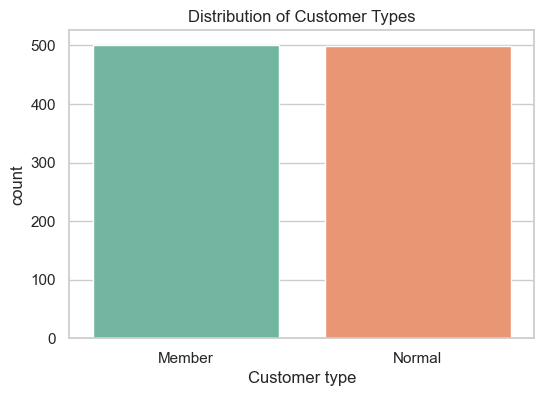

In [4]:
# 1. Distribution of Customer Types
plt.figure(figsize=(6, 4))
sns.countplot(x='Customer type', data=df, palette='Set2')
plt.title('Distribution of Customer Types')
plt.show()

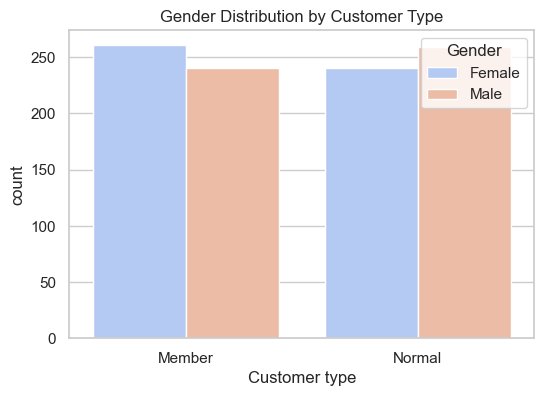

In [5]:
# 2. Gender Distribution by Customer Type
plt.figure(figsize=(6, 4))
sns.countplot(x='Customer type', hue='Gender', data=df, palette='coolwarm')
plt.title('Gender Distribution by Customer Type')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_14576\3603563373.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Customer type', y='gross income', data=df, palette='pastel')


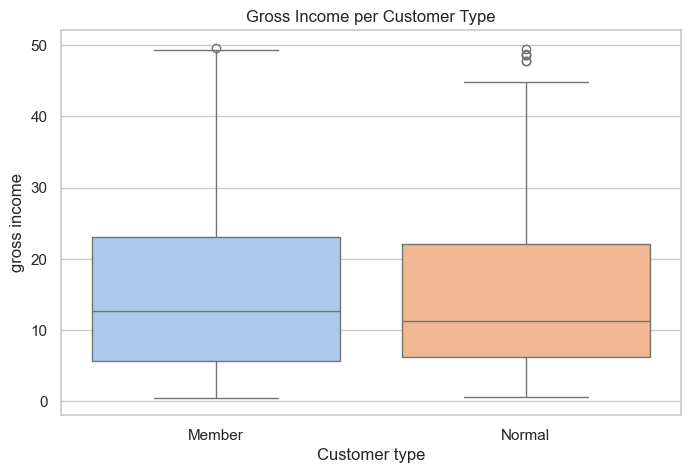

In [6]:
# 3. Gross Income vs. Customer Type
plt.figure(figsize=(8, 5))
sns.boxplot(x='Customer type', y='gross income', data=df, palette='pastel')
plt.title('Gross Income per Customer Type')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_14576\1902932555.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Product line', data=df, order=df['Product line'].value_counts().index, palette='viridis')


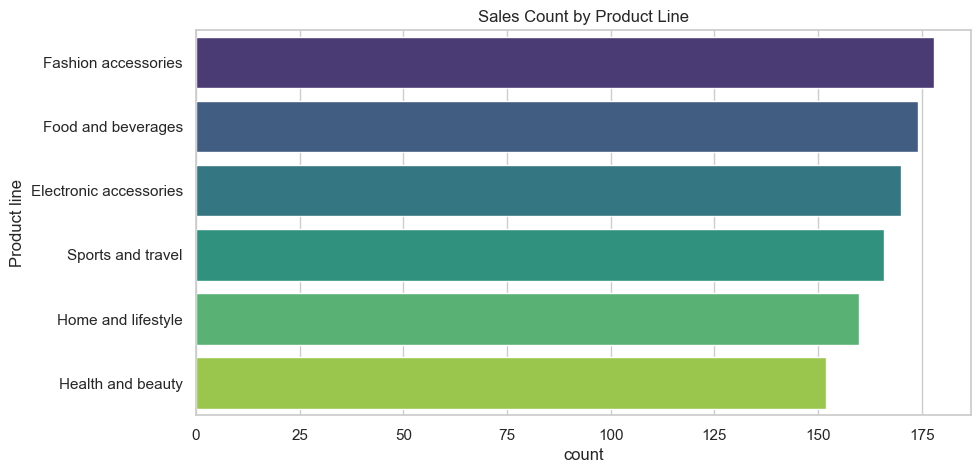

In [7]:
# 4. Product Line Popularity
plt.figure(figsize=(10, 5))
sns.countplot(y='Product line', data=df, order=df['Product line'].value_counts().index, palette='viridis')
plt.title('Sales Count by Product Line')
plt.show()

In [8]:
features = ['Unit price', 'Quantity', 'Total', 'gross income', 'Gender', 'Branch', 'Product line']
dataset = df[features + ['Customer type']].dropna().copy()
X = dataset[features].copy()
y = dataset['Customer type']

In [9]:
encoder = LabelEncoder()
X['Gender'] = encoder.fit_transform(X['Gender'])
X['Branch'] = encoder.fit_transform(X['Branch'])
X['Product line'] = encoder.fit_transform(X['Product line'])
y = encoder.fit_transform(y)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [12]:
y_pred = nb_model.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Accuracy: 49.00%

Confusion Matrix:
[[50 47]
 [55 48]]

Classification Report:
              precision    recall  f1-score   support

      Member       0.48      0.52      0.50        97
      Normal       0.51      0.47      0.48       103

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.49      0.49      0.49       200



In [14]:
joblib.dump(nb_model, 'naive_bayes_model.pkl')
joblib.dump(encoder, 'label_encoder.pkl')
print('Model and encoder saved successfully.')

Model and encoder saved successfully.
